# 6G GNN-DRL Network Optimization — Exploration


In [1]:
import sys; sys.path.insert(0, '..')
import yaml, numpy as np, matplotlib.pyplot as plt
from utils.graph_builder import build_networkx_graph, build_network_graph
from utils.metrics import compute_throughput, compute_sinr, compute_fairness_index
from envs.network_env import NetworkEnv

with open('../configs/config.yaml') as f:
    config = yaml.safe_load(f)
print(config)

{'network': {'num_base_stations': 10, 'num_users': 30, 'area_size': 1000, 'frequency_ghz': 28, 'max_bandwidth_mhz': 400}, 'training': {'episodes': 500, 'lr': 0.001, 'gamma': 0.99, 'batch_size': 64}}


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


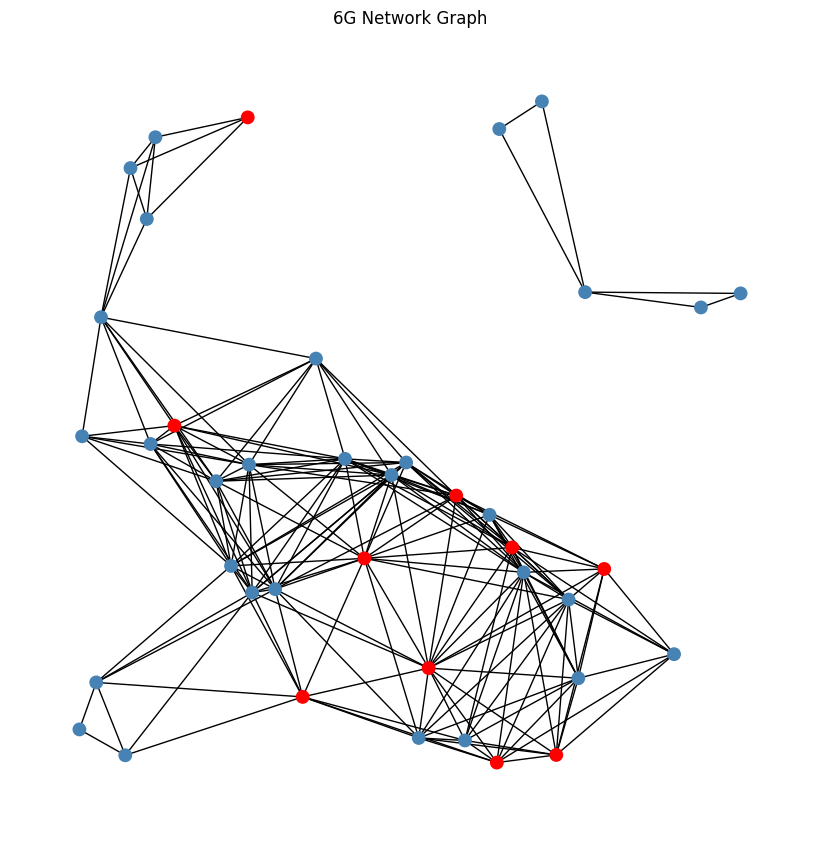

In [2]:
# Visualize a random network topology
import networkx as nx
net = config['network']
bs_pos = np.random.uniform(0, net['area_size'], (net['num_base_stations'], 2))
user_pos = np.random.uniform(0, net['area_size'], (net['num_users'], 2))
G = build_networkx_graph(bs_pos, user_pos)

pos = nx.get_node_attributes(G, 'pos')
colors = ['red' if G.nodes[n]['type'] == 'bs' else 'steelblue' for n in G.nodes]
plt.figure(figsize=(8, 8))
nx.draw(G, pos={n: p for n, p in pos.items()}, node_color=colors, node_size=80, with_labels=False)
plt.title('6G Network Graph')
plt.show()

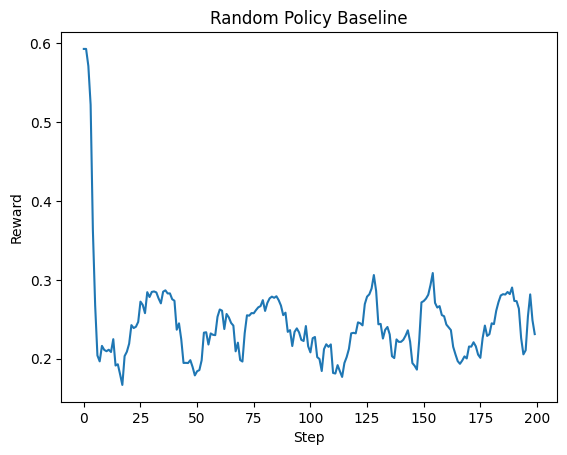

Total reward: 48.839


In [3]:
# Run a random-policy episode and plot rewards
env = NetworkEnv(config)
state = env.reset()
rewards = []
done = False
while not done:
    action = env.action_space.sample()
    state, reward, done, _ = env.step(action)
    rewards.append(reward)

plt.plot(rewards)
plt.xlabel('Step'); plt.ylabel('Reward')
plt.title('Random Policy Baseline')
plt.show()
print(f'Total reward: {sum(rewards):.3f}')